# Comparing tumor samples: differential gene expression (DGE) analysis
The analysis includes three pairwise comparisons, each specifying the *case* and *control* groups used for pseudobulk differential expression:

1. **Pdl1_wt + C57_wt vs Pdl1_cre**  
   - **Case:** `Pdl1_cre`  
   - **Control:** `Pdl1_wt`, `C57_wt`  
   Tests for gene expression differences in *Pdl1_cre* samples relative to both wild-type backgrounds combined.

2. **Pdl1_wt vs Pdl1_cre**  
   - **Case:** `Pdl1_cre`  
   - **Control:** `Pdl1_wt`  
   Focuses specifically on differences between *Pdl1_cre* and its wild-type littermate strain.

3. **Oprl1_cre vs C57_wt**  
   - **Case:** `Oprl1_cre`  
   - **Control:** `C57_wt`  
   Evaluates expression changes associated with *Oprl1_cre* relative to *C57BL/6 wild-type* controls.



In [1]:
import scanpy as sc
import matplotlib.pyplot as plt

In [2]:
ad = sc.read_h5ad('../../data/talbot_xenium.h5ad')
ad = ad[ad.obs.tissue == 'tumor']
ad

View of AnnData object with n_obs × n_vars = 279424 × 5006
    obs: 'x_centroid', 'y_centroid', 'transcript_counts', 'control_probe_counts', 'genomic_control_counts', 'control_codeword_counts', 'unassigned_codeword_counts', 'deprecated_codeword_counts', 'total_counts', 'cell_area', 'nucleus_area', 'nucleus_count', 'segmentation_method', 'run', 'sample_folder', 'sample___', 'condition', 'tissue', 'genotype', 'timepoint', 'seg_method_short', 'n_genes_by_counts', 'sample_id'
    var: 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts'
    obsm: 'spatial'

In [3]:
to_keep = [
    'output-XETG00045__0059973__Pdl1_wt__20250725__091031_1',
    'output-XETG00045__0059973__Pdl1_wt__20250725__091031_0',
    'output-XETG00045__0059973__Oprl1_cre__20250725__091031_1',
    'output-XETG00045__0059973__Oprl1_cre__20250725__091031_0',
    'output-XETG00045__0059973__c57__20250725__091031_2',
    'output-XETG00045__0059973__c57__20250725__091031_1',
    'output-XETG00045__0059973__c57__20250725__091031_0',
    #'output-XETG00045__0059973__Oprl1_wt__20250725__091031_0',
    'output-XETG00045__0059973__Pdl1_cre__20250725__091031_1',
    'output-XETG00045__0059973__Pdl1_cre__20250725__091031_3',
    'output-XETG00045__0059973__Pdl1_cre__20250725__091031_2',
    #'output-XETG00045__0059973__Pdl1_cre__20250725__091031_0'
]
ad = ad[ad.obs.sample_id.isin(to_keep)]

## 🔍 Quick Clustering

This initial clustering is **independent of the differential gene expression (DGE)** analysis but serves as an important **sanity check**.  
By running a quick clustering on the dataset (e.g., using PCA, neighbors, and Leiden), you can verify that:

- Samples or cells group according to expected biological or experimental conditions  
- There are no major batch effects or mislabeled samples  
- The overall structure of the data makes sense before performing DGE

This step helps ensure that downstream comparisons are biologically meaningful and not driven by technical artifacts.

In [4]:
sc.pp.calculate_qc_metrics(ad, percent_top=None, log1p=False, inplace=True)
sc.pp.filter_cells(ad,min_counts=30)
sc.pp.filter_cells(ad,min_genes=10)

/Users/christoffer/miniconda3/envs/sc/lib/python3.8/site-packages/scanpy/preprocessing/_qc.py:135: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata.obs[obs_metrics.columns] = obs_metrics


In [5]:
ad.layers['counts'] = ad.X.copy()

In [6]:
sc.pp.normalize_total(ad, inplace=True,target_sum=100)
sc.pp.log1p(ad)

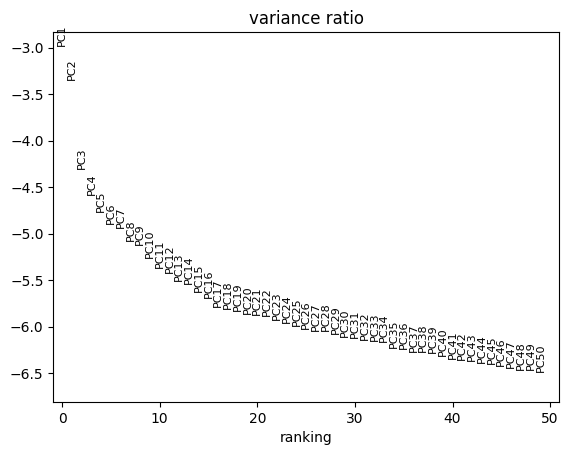

In [7]:
plt.rcdefaults()
sc.tl.pca(ad)
sc.pl.pca_variance_ratio(ad, n_pcs=50, log=True)
sc.pp.neighbors(ad, n_neighbors=15, n_pcs=30)

In [8]:
sc.tl.umap(ad, min_dist=0.1)

clustering at resolution 0.5


/Users/christoffer/miniconda3/envs/sc/lib/python3.8/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


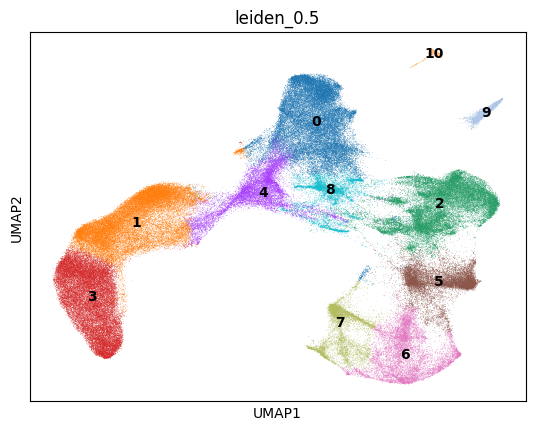

done
clustering at resolution 1


/Users/christoffer/miniconda3/envs/sc/lib/python3.8/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


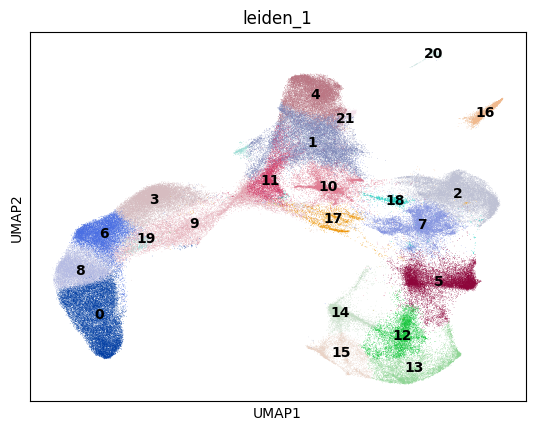

done


In [9]:
resolutions = [0.5, 1]
for resolution in resolutions: 
    print('clustering at resolution '+str(resolution))
    sc.tl.leiden(ad, resolution = resolution, key_added = 'leiden_'+str(resolution))
    sc.pl.umap(ad, color = 'leiden_'+str(resolution), legend_loc = 'on data')
    print("done")

## Plot spatial composition of samples

Pdl1_wt


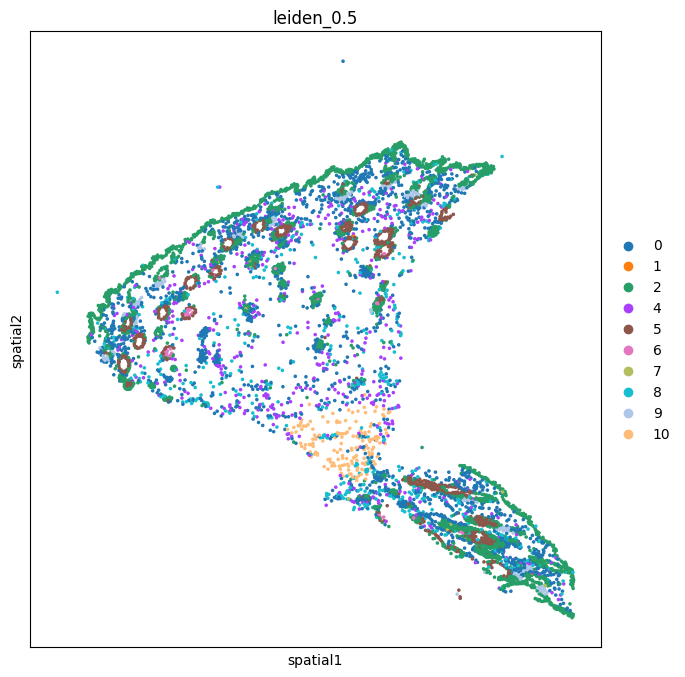

Pdl1_wt


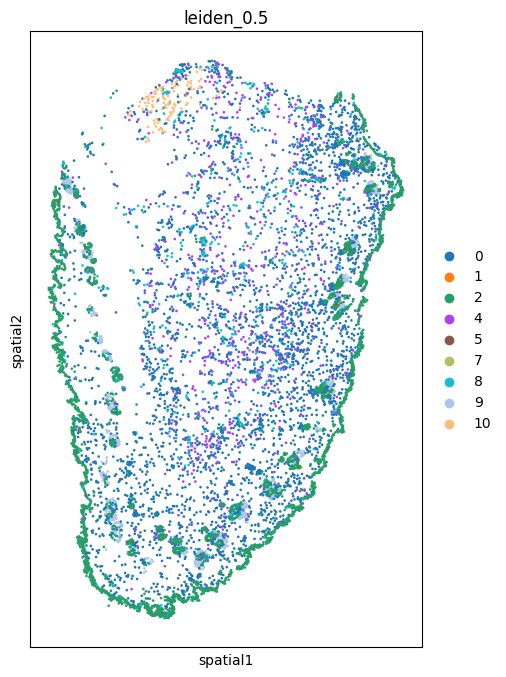

Oprl1_cre


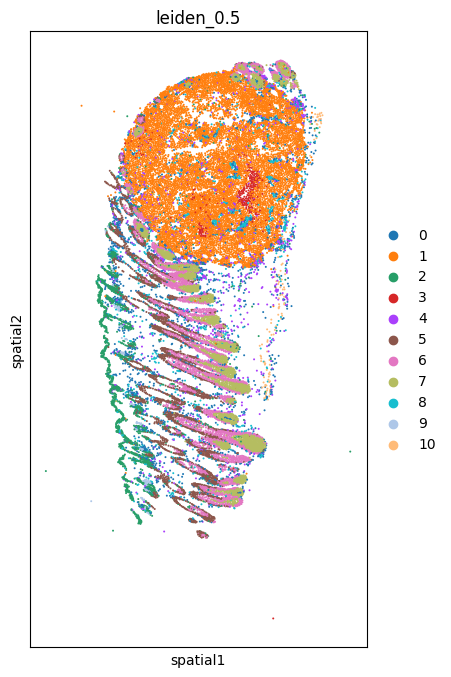

Oprl1_cre


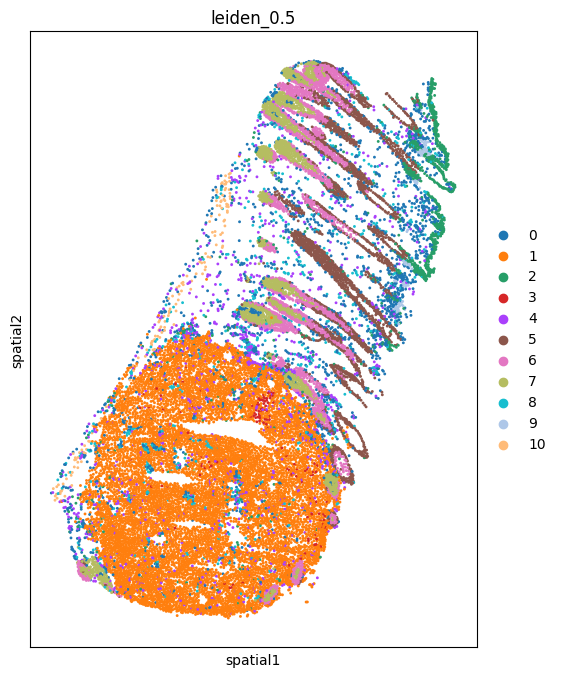

c57


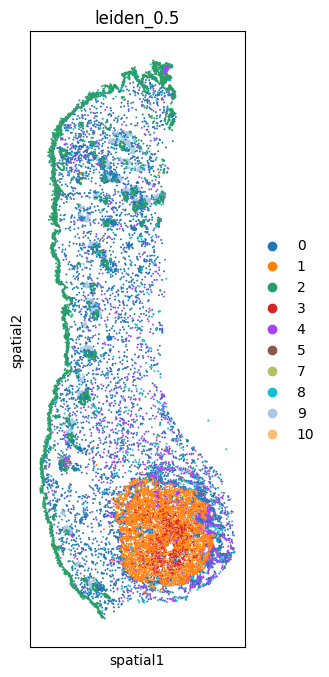

c57


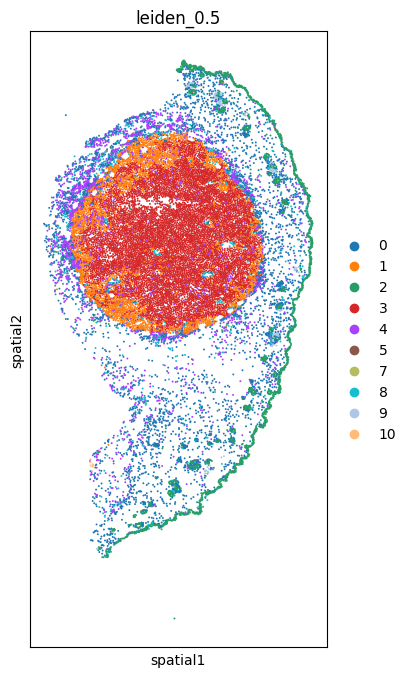

c57


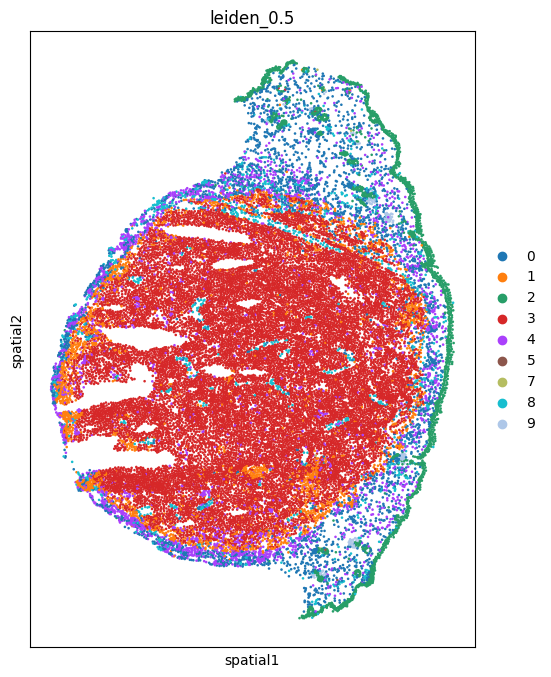

Pdl1_cre


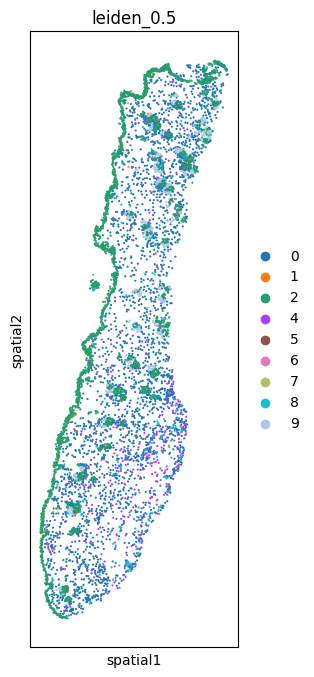

Pdl1_cre


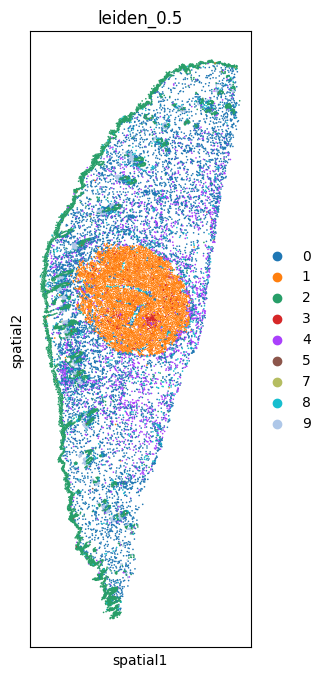

Pdl1_cre


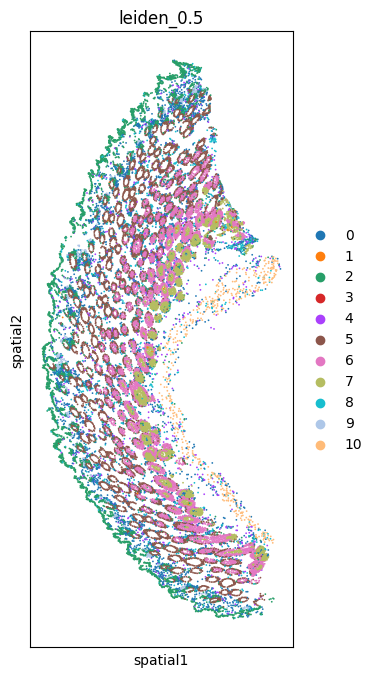

In [10]:
for grid in ad.obs['sample_id'].unique():    
    ad_int = ad[ad.obs['sample_id'] == grid]
    print(ad_int.obs.condition.unique()[0])
    with plt.rc_context({'figure.figsize': (10, 8)}):
        sc.pl.spatial(ad_int, spot_size=15, color = 'leiden_0.5')
    plt.show()


# Main analysis

## Specify comparisions

In [11]:
# 1) map each file prefix to a condition label
file_to_condition = {
    "output-XETG00045__0059973__Pdl1_wt__20250725__091031":  "Pdl1_wt",
    "output-XETG00045__0059973__c57__20250725__091031":      "C57_wt",
    "output-XETG00045__0059973__Pdl1_cre__20250725__091031": "Pdl1_cre",
    "output-XETG00045__0059973__Oprl1_cre__20250725__091031":"Oprl1_cre",
    "output-XETG00045__0059973__Oprl1_wt__20250725__091031": "Oprl1_wt",
}

# add condition column (sample_id should carry those prefixes)
ad.obs["condition"] = ad.obs["sample___"].map(file_to_condition)

# 2) define comparisons by condition
comparisons = {
    # 1) (Pdl1_wt + C57_wt) vs Pdl1_cre
    "Pdl1_wt+C57_vs_Pdl1_cre": {
        "case":    ["Pdl1_cre"],
        "control": ["Pdl1_wt", "C57_wt"],
    },
    # 2) Pdl1_wt vs Pdl1_cre
    "Pdl1_wt_vs_Pdl1_cre": {
        "case":    ["Pdl1_cre"],
        "control": ["Pdl1_wt"],
    },
    # 4) Oprl1_cre vs C57_wt
    "Oprl1_cre_vs_C57_wt": {
        "case":    ["Oprl1_cre"],
        "control": ["C57_wt"],
    },
}


In [46]:
import pandas as pd

# ---------- CONFIG ----------
COND_COL = "condition"
SAMPLE_COL = "sample_id"

# ---------- 1) Unique sample counts per condition ----------
sample_counts = (
    ad.obs.groupby(COND_COL)[SAMPLE_COL]
    .nunique()
    .sort_values(ascending=False)
)

print("📊 Unique samples per condition:")
for cond, n in sample_counts.items():
    print(f"  • {cond:<15} → {n} unique samples")

# ---------- 2) Map conditions → sample IDs ----------
cond_to_samples = (
    ad.obs.groupby(COND_COL)[SAMPLE_COL]
    .apply(lambda s: sorted(s.unique().tolist()))
    .to_dict()
)

print("\n🧬 Sample IDs per condition:")
for cond, sids in cond_to_samples.items():
    sid_list = ", ".join(sids)
    print(f"  • {cond:<15} ({len(sids)}) → {sid_list}")

# ---------- 3) Define condition-level comparisons ----------
comparisons = {
    "Pdl1_wt+C57_vs_Pdl1_cre": {"case": ["Pdl1_cre"], "control": ["Pdl1_wt", "C57_wt"]},
    "Pdl1_wt_vs_Pdl1_cre":     {"case": ["Pdl1_cre"], "control": ["Pdl1_wt"]},
    "Oprl1_cre_vs_C57_wt":     {"case": ["Oprl1_cre"], "control": ["C57_wt"]},
}

# ---------- 4) Expand comparisons to per-sample level ----------
def expand_comparisons_to_samples(comparisons, cond_to_samples):
    """
    Expand condition-level comparisons into sample-level groupings.
    Returns:
        dict: {comparison_name: {'case_samples': [...], 'control_samples': [...]}}
    """
    out = {}
    for name, spec in comparisons.items():
        case_conditions = spec["case"]
        ctrl_conditions = spec["control"]

        # Collect sample IDs for each group
        case_samples = sum([cond_to_samples.get(c, []) for c in case_conditions], [])
        ctrl_samples = sum([cond_to_samples.get(c, []) for c in ctrl_conditions], [])

        # Sanity checks
        overlap = set(case_samples) & set(ctrl_samples)
        if overlap:
            print(f"[WARN] Overlapping samples in {name}: {sorted(overlap)}")
        if len(case_samples) == 0 or len(ctrl_samples) == 0:
            print(f"[WARN] Empty group in {name}: case={len(case_samples)}, control={len(ctrl_samples)}")

        out[name] = {"case_samples": case_samples, "control_samples": ctrl_samples}
    return out


expanded = expand_comparisons_to_samples(comparisons, cond_to_samples)

# ---------- 5) Display expanded mapping ----------
print("\n🔍 Expanded comparisons (per-sample):")
for name, groups in expanded.items():
    print(f"\n{name}")
    print(f"  🧪 Case samples    ({len(groups['case_samples'])}):    {groups['case_samples']}")
    print(f"  🎛️ Control samples ({len(groups['control_samples'])}): {groups['control_samples']}")

📊 Unique samples per condition:
  • Pdl1_cre        → 3 unique samples
  • C57_wt          → 3 unique samples
  • Oprl1_cre       → 2 unique samples
  • Pdl1_wt         → 2 unique samples

🧬 Sample IDs per condition:
  • Oprl1_cre       (2) → output-XETG00045__0059973__Oprl1_cre__20250725__091031_0, output-XETG00045__0059973__Oprl1_cre__20250725__091031_1
  • Pdl1_cre        (3) → output-XETG00045__0059973__Pdl1_cre__20250725__091031_1, output-XETG00045__0059973__Pdl1_cre__20250725__091031_2, output-XETG00045__0059973__Pdl1_cre__20250725__091031_3
  • Pdl1_wt         (2) → output-XETG00045__0059973__Pdl1_wt__20250725__091031_0, output-XETG00045__0059973__Pdl1_wt__20250725__091031_1
  • C57_wt          (3) → output-XETG00045__0059973__c57__20250725__091031_0, output-XETG00045__0059973__c57__20250725__091031_1, output-XETG00045__0059973__c57__20250725__091031_2

🔍 Expanded comparisons (per-sample):

Pdl1_wt+C57_vs_Pdl1_cre
  🧪 Case samples    (3):    ['output-XETG00045__0059973__Pdl1_cre

## Save transformed data 

In [16]:
ad.layers['transformed'] = ad.X.copy()

In [17]:
ad.X = ad.layers['counts']

In [18]:
ad.X.max()

408.0

## Pseudobulking and differential gene expression

In [19]:
# =========================
# PSEUDOBULK + DE (from scratch)
# =========================
import numpy as np, pandas as pd
from scipy import sparse, stats
from statsmodels.stats.multitest import multipletests

# ---------- USER CONFIG ----------
COND_COL       = "condition"   # ad.obs column with condition labels
SAMPLE_COL     = "sample_id"   # ad.obs column with sample identifiers (replicates)
CELLTYPE_COL   = None          # e.g. "cell_type" to stratify; or None to pool all cells
MIN_TOTAL_COUNTS = 10          # prefilter genes: total pseudobulk counts across all samples >= this
PRIOR_COUNT      = 1.0         # logCPM prior
FDR_ALPHA        = 0.05

# Define comparisons by condition labels in ad.obs[COND_COL]
comparisons = {
    "Pdl1_wt+C57_vs_Pdl1_cre": {"case": ["Pdl1_cre"], "control": ["Pdl1_wt", "C57_wt"]},
    "Pdl1_wt_vs_Pdl1_cre":     {"case": ["Pdl1_cre"], "control": ["Pdl1_wt"]},
    "Oprl1_cre_vs_C57_wt":   {"case": ["Oprl1_cre"], "control": ["C57_wt"]},
}

# ---------- HELPERS ----------
def get_counts_and_genes(adata):
    """
    Returns (X, genes) where X is cells×genes counts and 'genes' matches X.
    Priority: layers['raw'] > layers['counts'] > ad.raw.X
    """
    if "raw" in adata.layers:
        X = adata.layers["raw"]
        genes = adata.var_names
    elif "counts" in adata.layers:
        X = adata.layers["counts"]
        genes = adata.var_names
    elif adata.raw is not None:
        X = adata.raw.X
        genes = adata.raw.var_names
    else:
        raise ValueError("No counts found. Expected ad.layers['raw'] or ['counts'] or ad.raw.X.")
    return X, pd.Index(genes)

def logcpm(counts, lib_sizes=None, prior_count=1.0, scale=1e6):
    """
    Log2-CPM with prior (edgeR-style).
    counts: genes×samples dense array
    """
    if lib_sizes is None:
        lib_sizes = counts.sum(axis=0)
    lib_sizes = np.asarray(lib_sizes, dtype=float).reshape(1, -1)
    cpm = (counts * scale) / np.maximum(lib_sizes, 1.0)
    return np.log2(cpm + prior_count)

def sanitize_pvals(p):
    """Replace NaN/Inf with 1, clip into (tiny,1]."""
    p = np.asarray(p, dtype=float)
    p[~np.isfinite(p)] = 1.0
    return np.clip(p, np.finfo(float).tiny, 1.0)

# ---------- CORE: PSEUDOBULK ----------
def pseudobulk_by_sample(adata, celltype_col=None):
    """
    Returns:
      pb_counts: DataFrame [genes × samples]
      sample_meta: DataFrame with columns [group_key, sample_id, condition, (celltype?)]
    """
    X, genes = get_counts_and_genes(adata)  # cells×genes
    X = X.tocsr() if sparse.issparse(X) else np.asarray(X)

    cols = [SAMPLE_COL, COND_COL] + ([celltype_col] if celltype_col else [])
    obs = adata.obs[cols].copy()

    group_key_cols = [SAMPLE_COL] + ([celltype_col] if celltype_col else [])
    key_df = obs[group_key_cols].astype(str)
    key_df["_grp"] = key_df.apply(lambda r: "||".join(r.values.tolist()), axis=1)
    groups, inv = np.unique(key_df["_grp"].values, return_inverse=True)

    G = len(groups)
    pb = np.zeros((X.shape[1], G), dtype=np.float64)  # genes×groups
    for g in range(G):
        idx = np.where(inv == g)[0]
        if len(idx) == 0:
            continue
        if sparse.issparse(X):
            pb[:, g] = X[idx, :].sum(axis=0).A1
        else:
            pb[:, g] = X[idx, :].sum(axis=0)

    # Build sample metadata (and map condition per sample_id)
    meta_parts = [g.split("||") for g in groups]
    meta_cols = [SAMPLE_COL] + ([celltype_col] if celltype_col else [])
    sample_meta = pd.DataFrame(meta_parts, columns=meta_cols)

    cond_map = (obs.groupby(SAMPLE_COL)[COND_COL]
                  .agg(lambda s: s.unique()[0] if s.nunique()==1 else s.mode().iloc[0])
                  .to_dict())
    sample_meta[COND_COL] = sample_meta[SAMPLE_COL].map(cond_map)

    colnames = [
        f"{r[SAMPLE_COL]}" + (f"|{r[celltype_col]}" if celltype_col else "")
        for _, r in sample_meta.iterrows()
    ]
    pb_counts = pd.DataFrame(pb, index=genes, columns=colnames)
    sample_meta["group_key"] = colnames

    # Drop any all-zero columns (rare but safe)
    keep_cols = pb_counts.sum(axis=0) > 0
    if (~keep_cols).any():
        pb_counts = pb_counts.loc[:, keep_cols.values]
        sample_meta = sample_meta.loc[keep_cols.values].reset_index(drop=True)

    return pb_counts, sample_meta

# ---------- CORE: DE ----------
def run_de_welch_logcpm(logcpm_mat, sample_meta, case_conditions, ctrl_conditions):
    """
    Welch's t-test on logCPM for case vs control.
    Returns a tidy DE DataFrame indexed by gene.
    """
    sel_case = sample_meta[sample_meta[COND_COL].isin(case_conditions)]["group_key"].tolist()
    sel_ctrl = sample_meta[sample_meta[COND_COL].isin(ctrl_conditions)]["group_key"].tolist()
    n_case, n_ctrl = len(sel_case), len(sel_ctrl)
    if n_case < 2 or n_ctrl < 2:
        print(f"[WARN] Low replicate counts: case={n_case}, control={n_ctrl}. Stats will be weak.")

    Xc = logcpm_mat[sel_case].to_numpy()  # genes×n_case
    Xn = logcpm_mat[sel_ctrl].to_numpy()  # genes×n_ctrl

    mean_case = Xc.mean(axis=1)
    mean_ctrl = Xn.mean(axis=1)
    log2fc = mean_case - mean_ctrl

    t_stat, pvals = stats.ttest_ind(Xc, Xn, equal_var=False, axis=1, nan_policy="omit")
    pvals = sanitize_pvals(pvals)
    padj = multipletests(pvals, method="fdr_bh")[1]

    de = pd.DataFrame({
        "gene": logcpm_mat.index.values,
        "log2fc": log2fc,
        "pval": pvals,
        "padj": padj,
        "mean_logCPM_case": mean_case,
        "mean_logCPM_ctrl": mean_ctrl,
        "n_case_samples": n_case,
        "n_ctrl_samples": n_ctrl,
        "mode": "pseudobulk_mean",
    }).set_index("gene").sort_values(["padj","pval","log2fc"], ascending=[True,True,False])

    return de

# ---------- DRIVER ----------
def run_pseudobulk_de(adata, comparisons, celltype_col=None,
                      min_total_counts=MIN_TOTAL_COUNTS, prior_count=PRIOR_COUNT, alpha=FDR_ALPHA):
    # 1) pseudobulk
    pb_counts, sample_meta = pseudobulk_by_sample(adata, celltype_col=celltype_col)

    # 2) crude prefilter BEFORE logCPM
    if min_total_counts is not None and min_total_counts > 0:
        keep = (pb_counts.sum(axis=1) >= min_total_counts)
        pb_counts = pb_counts.loc[keep]

    # 3) logCPM
    lib_sizes = pb_counts.sum(axis=0).values
    logcpm_mat = pd.DataFrame(
        logcpm(pb_counts.values, lib_sizes=lib_sizes, prior_count=prior_count, scale=1e6),
        index=pb_counts.index, columns=pb_counts.columns
    )

    # 4) DE per comparison
    results = {}
    for name, spec in comparisons.items():
        de = run_de_welch_logcpm(logcpm_mat, sample_meta, spec["case"], spec["control"])
        results[name] = de
        # quick summary
        sig = (de["padj"] <= alpha).sum()
        print(f"\n=== {name} ===")
        print(f"tested genes: {de.shape[0]} | significant @ FDR≤{alpha}: {sig}")
        print(de.head(10)[["log2fc","pval","padj","n_case_samples","n_ctrl_samples"]])

    return results, pb_counts, sample_meta, logcpm_mat

# ----------------- RUN -----------------
results, pb_counts, sample_meta, logcpm_mat = run_pseudobulk_de(
    ad, comparisons, celltype_col=CELLTYPE_COL,
    min_total_counts=MIN_TOTAL_COUNTS, prior_count=PRIOR_COUNT, alpha=FDR_ALPHA
)



=== Pdl1_wt+C57_vs_Pdl1_cre ===
tested genes: 4934 | significant @ FDR≤0.05: 0
           log2fc      pval      padj  n_case_samples  n_ctrl_samples
gene                                                                 
Tubb1    0.792672  0.001139  0.938195               3               5
Grm2     1.157414  0.001188  0.938195               3               5
Acss1   -0.777115  0.001412  0.938195               3               5
Grk2    -0.390584  0.001799  0.938195               3               5
Pou6f1  -1.191725  0.002611  0.938195               3               5
Adipor1 -0.421494  0.002966  0.938195               3               5
Mpl      0.743518  0.002973  0.938195               3               5
Stimate -0.760863  0.003267  0.938195               3               5
Limd1   -0.425356  0.003471  0.938195               3               5
Smap1    0.138063  0.003504  0.938195               3               5

=== Pdl1_wt_vs_Pdl1_cre ===
tested genes: 4934 | significant @ FDR≤0.05: 0
    

In [38]:
combined_results = pd.concat(results, names=["comparison"])
combined_results = combined_results.reset_index(level="comparison").reset_index(drop=True)

## Export data for customer

In [43]:
combined_results.to_csv('../../results/differential-gene-expression/pseudobulk_comparision.csv')

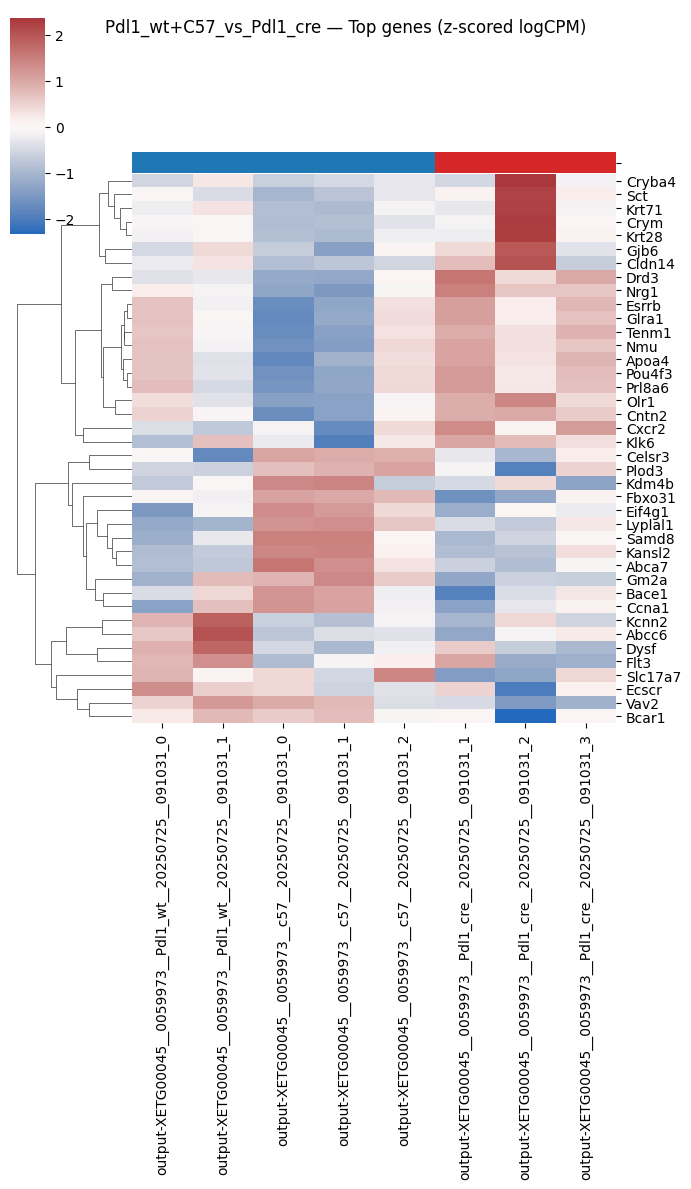

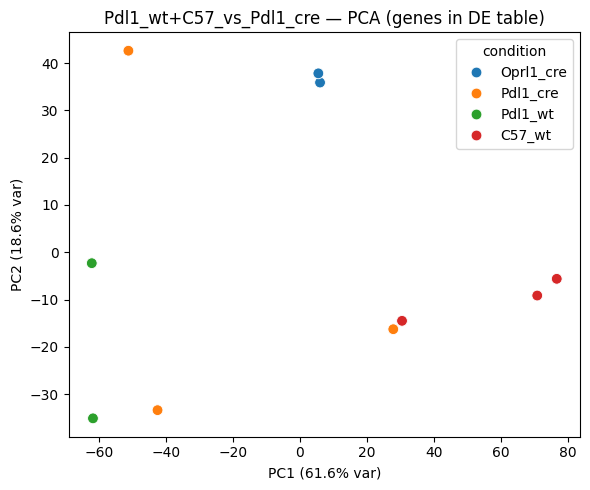

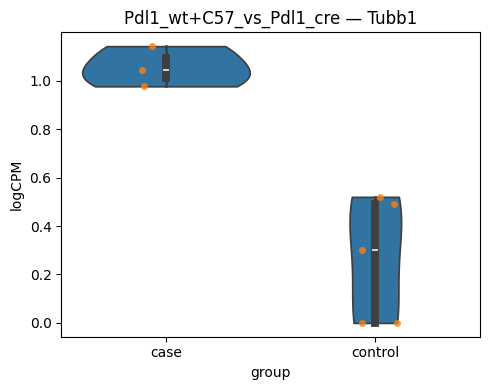

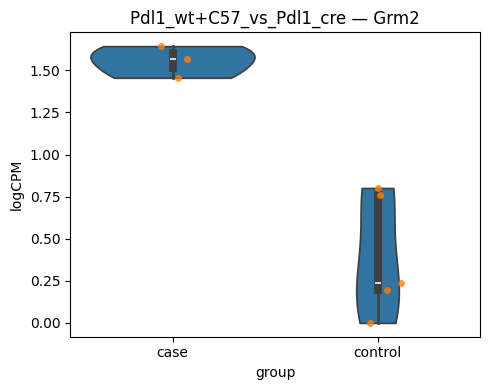

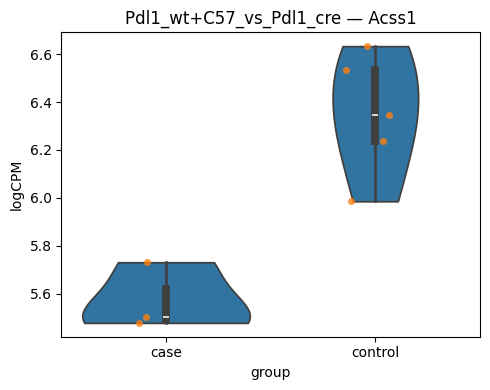

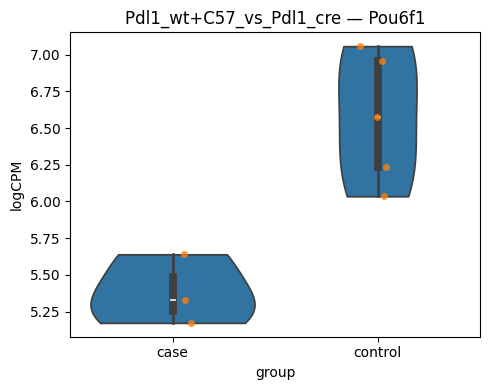

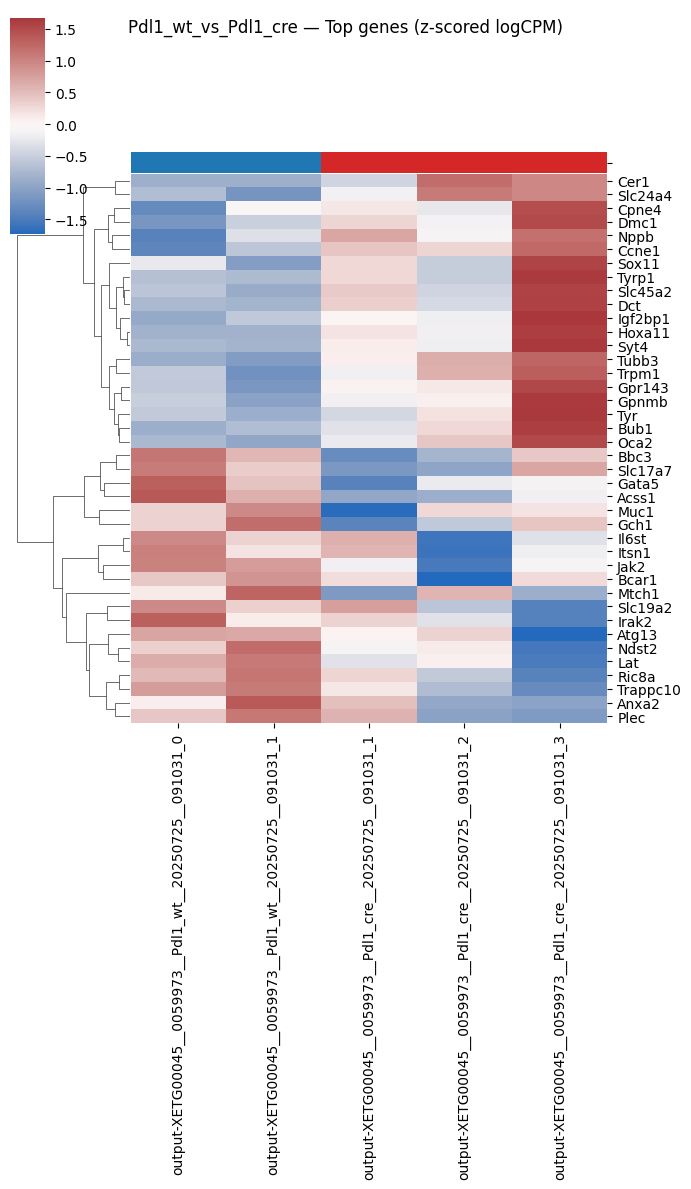

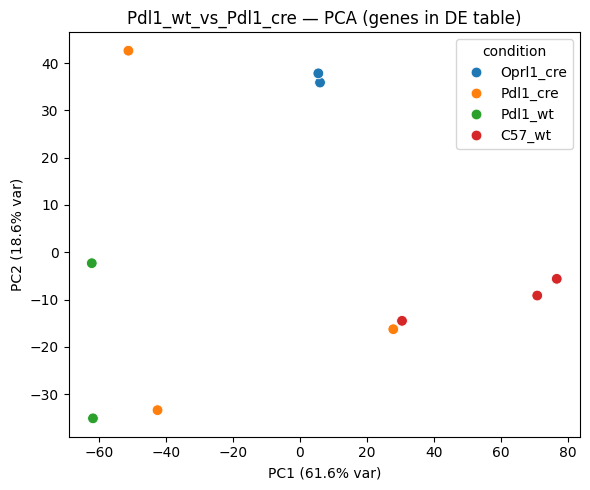

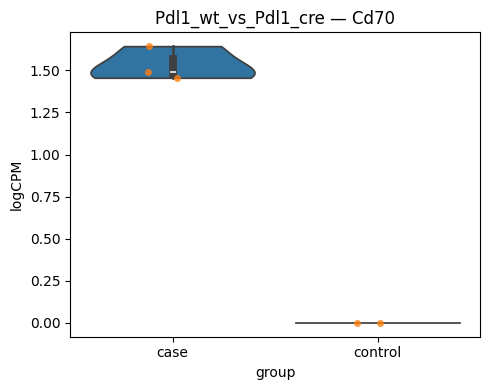

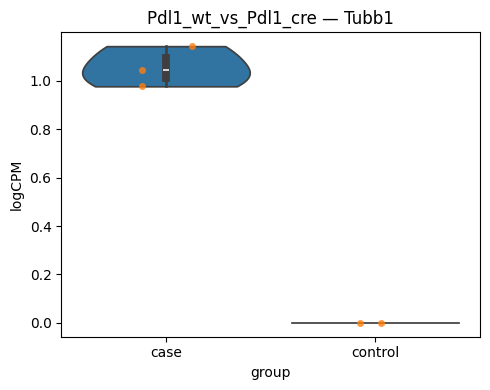

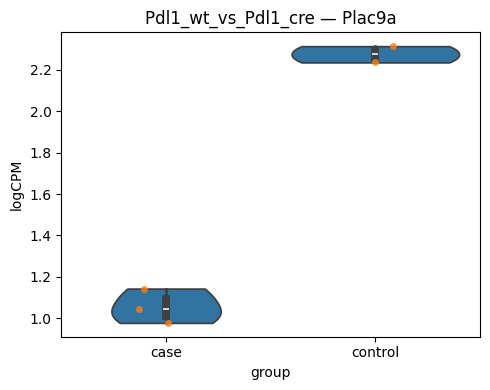

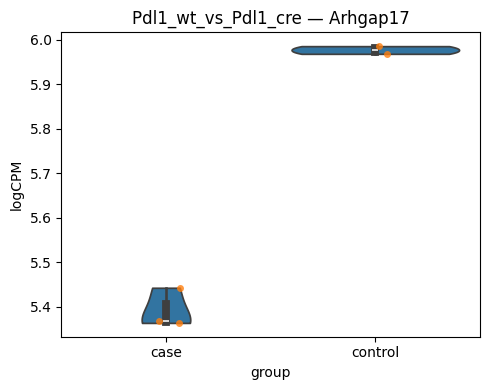

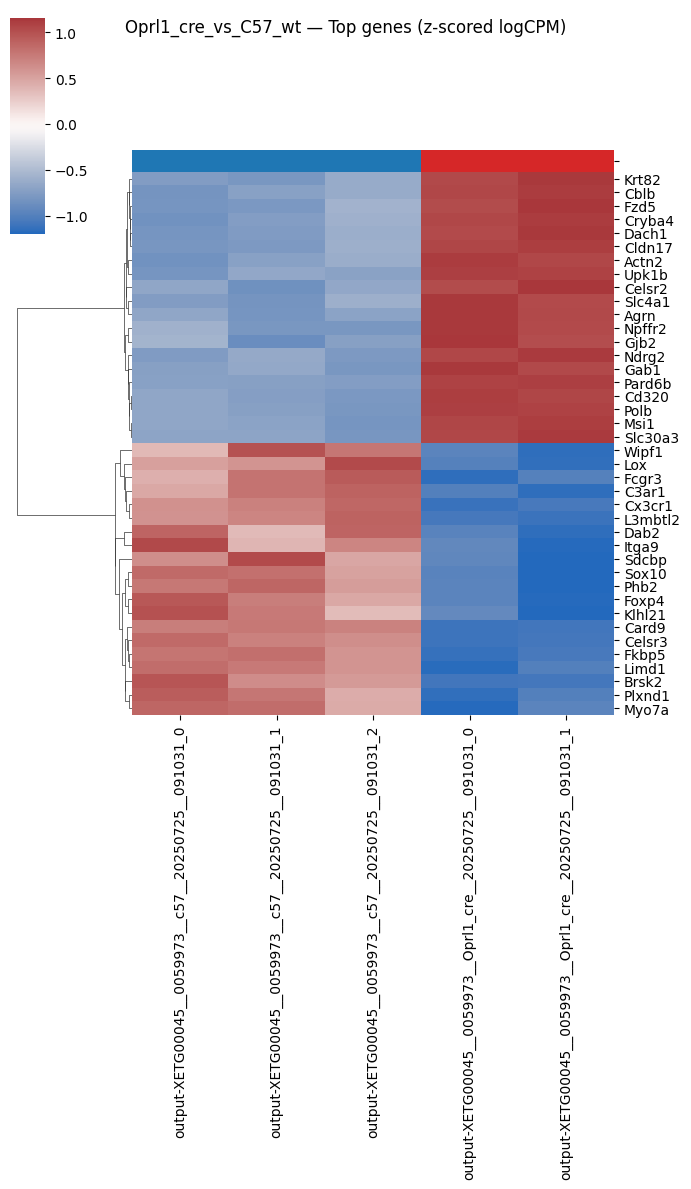

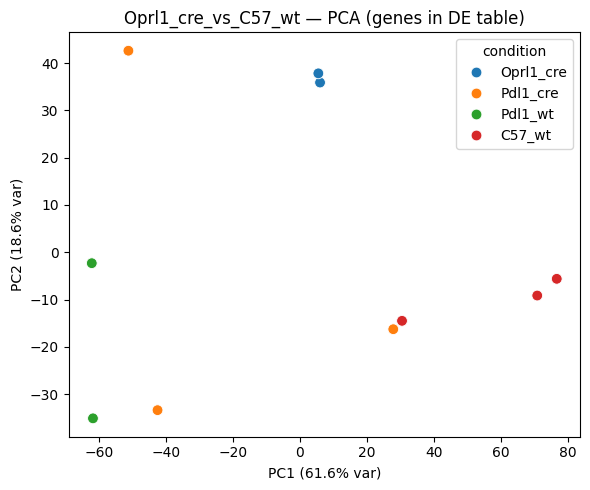

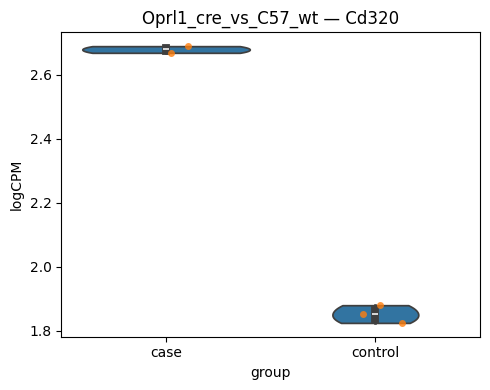

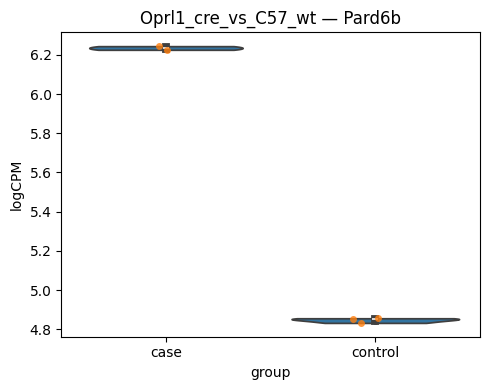

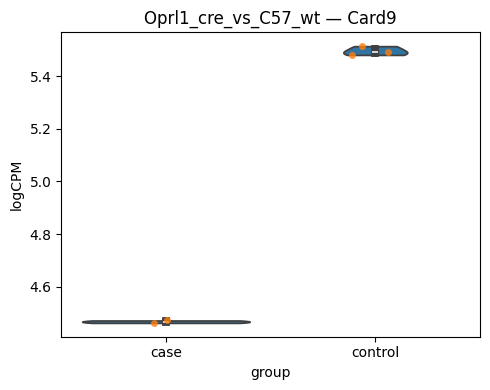

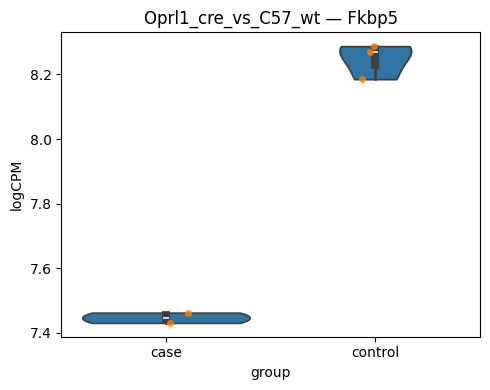

In [21]:
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA

# ---------- CONFIG ----------
FDR_THR  = 1
LFC_THR  = 0.5
TOP_N    = 20
FIGSIZE  = (6,5)

def _sig_mask(df, fdr_thr=FDR_THR, lfc_thr=LFC_THR):
    return (df["padj"] <= fdr_thr) & (df["log2fc"].abs() >= lfc_thr)

# ---------- VOLCANO ----------
def plot_volcano(de, title="", fdr_thr=FDR_THR, lfc_thr=LFC_THR, top_n=TOP_N, annotate=True):
    df = de.copy()
    # Handle filtered genes (padj NaN) by setting for plotting only
    df["padj_plot"] = df["padj"].fillna(1.0)
    df["neglog10_padj"] = -np.log10(df["padj_plot"].clip(lower=1e-300))

    sig = (df["padj_plot"] <= fdr_thr) & (df["log2fc"].abs() >= lfc_thr)

    plt.figure(figsize=FIGSIZE)
    plt.scatter(df.loc[~sig, "log2fc"], df.loc[~sig, "neglog10_padj"], s=8, alpha=0.4)
    plt.scatter(df.loc[sig,  "log2fc"], df.loc[sig,  "neglog10_padj"], s=10, alpha=0.85)

    plt.axvline(+lfc_thr, ls="--", lw=1, color="grey")
    plt.axvline(-lfc_thr, ls="--", lw=1, color="grey")
    plt.axhline(-np.log10(fdr_thr), ls="--", lw=1, color="grey")

    plt.xlabel("log2FC (case vs control)")
    plt.ylabel("-log10(FDR)")
    plt.title(title or "Volcano")

    if annotate:
        # label significant if any; else label top_n by raw p
        if sig.any():
            lab = df[sig].nsmallest(top_n, "padj_plot")
        else:
            lab = df.nsmallest(top_n, "pval")
        for g, r in lab.iterrows():
            plt.text(r["log2fc"], r["neglog10_padj"], g, fontsize=7, ha="left", va="bottom", alpha=0.8)

    plt.tight_layout()
    plt.show()

# ---------- MA ----------
def plot_ma(de, title="MA"):
    df = de.copy()
    df["A"] = (df["mean_logCPM_case"] + df["mean_logCPM_ctrl"]) / 2.0
    sig = _sig_mask(df)

    plt.figure(figsize=FIGSIZE)
    plt.scatter(df.loc[~sig,"A"], df.loc[~sig,"log2fc"], s=8, alpha=0.4)
    plt.scatter(df.loc[sig, "A"], df.loc[sig, "log2fc"], s=10, alpha=0.85)
    plt.axhline(0, ls="--", lw=1, color="grey")
    plt.xlabel("Mean logCPM")
    plt.ylabel("log2FC (case vs control)")
    plt.title(title)
    plt.tight_layout()
    plt.show()

# ---------- HEATMAP (top DE genes) ----------
def plot_heatmap_top(de, logcpm_mat, sample_meta, case_conditions, ctrl_conditions,
                     top_n=TOP_N, title="Top DE genes (z-scored logCPM)"):
    df = de.copy()
    tested = df[~df["padj"].isna()]  # only genes actually tested

    if tested.empty:
        print("[info] No tested genes to display.")
        return

    # Prefer significant genes; else fallback to best by raw p
    candidates = tested[_sig_mask(tested)]
    if candidates.empty:
        candidates = tested.nsmallest(2*top_n, "pval")  # symmetric-ish size
    else:
        # take top_n up + top_n down by FDR then |LFC|
        up = candidates[candidates["log2fc"]>0].sort_values(["padj","log2fc"], ascending=[True,False]).head(top_n)
        dn = candidates[candidates["log2fc"]<0].sort_values(["padj","log2fc"], ascending=[True,False]).head(top_n)
        candidates = pd.concat([up, dn])

    genes = candidates.index.tolist()

    case_cols = sample_meta[sample_meta["condition"].isin(case_conditions)]["group_key"].tolist()
    ctrl_cols = sample_meta[sample_meta["condition"].isin(ctrl_conditions)]["group_key"].tolist()
    cols = ctrl_cols + case_cols  # controls first, then cases

    M = logcpm_mat.loc[genes, cols]
    Z = (M - M.mean(axis=1).values[:,None]) / (M.std(axis=1).values[:,None] + 1e-9)

    # condition color bar
    col_colors = pd.Series(index=cols, dtype="object")
    for c in ctrl_cols: col_colors[c] = "tab:blue"
    for c in case_cols: col_colors[c] = "tab:red"

    g = sns.clustermap(Z, row_cluster=True, col_cluster=False, cmap="vlag",
                       col_colors=col_colors[cols], figsize=(7,12))
    g.fig.suptitle(title)
    plt.show()

# ---------- PCA (samples) ----------
def plot_sample_pca(logcpm_mat, sample_meta, title="PCA (samples)"):
    X = logcpm_mat.T  # samples × genes
    Xc = X - X.mean(axis=0)
    pca = PCA(n_components=2, random_state=0).fit(Xc)
    PCs = pca.transform(Xc)
    dfp = pd.DataFrame(PCs, index=X.index, columns=["PC1","PC2"]).reset_index().rename(columns={"index":"group_key"})
    dfp = dfp.merge(sample_meta[["group_key","condition"]], on="group_key", how="left")

    plt.figure(figsize=FIGSIZE)
    sns.scatterplot(data=dfp, x="PC1", y="PC2", hue="condition", s=60)
    ve = pca.explained_variance_ratio_ * 100
    plt.xlabel(f"PC1 ({ve[0]:.1f}% var)")
    plt.ylabel(f"PC2 ({ve[1]:.1f}% var)")
    plt.title(title)
    plt.tight_layout()
    plt.show()

# ---------- Per-gene violin ----------
def plot_gene_violin(gene, logcpm_mat, sample_meta, case_conditions, ctrl_conditions, title=None):
    case_cols = sample_meta[sample_meta["condition"].isin(case_conditions)]["group_key"].tolist()
    ctrl_cols = sample_meta[sample_meta["condition"].isin(ctrl_conditions)]["group_key"].tolist()

    data = []
    for c in case_cols:
        data.append({"group":"case", "value": logcpm_mat.at[gene, c], "sample": c})
    for c in ctrl_cols:
        data.append({"group":"control", "value": logcpm_mat.at[gene, c], "sample": c})
    df = pd.DataFrame(data)

    plt.figure(figsize=(5,4))
    sns.violinplot(data=df, x="group", y="value", inner="box", cut=0)
    sns.stripplot(data=df, x="group", y="value", alpha=0.8, jitter=0.15)
    plt.ylabel("logCPM")
    plt.title(title or gene)
    plt.tight_layout()
    plt.show()

# ---------- Driver to render a full panel for ONE comparison ----------
def visualize_comparison(name, results, sample_meta, logcpm_mat, comparisons,
                         fdr_thr=FDR_THR, lfc_thr=LFC_THR, top_n=TOP_N, show_example_violins=True):
    de = results[name]
    case_conds = comparisons[name]["case"]
    ctrl_conds = comparisons[name]["control"]

    # Volcano / MA
    #plot_volcano(de, title=f"{name} — Volcano", fdr_thr=fdr_thr, lfc_thr=lfc_thr, top_n=top_n)
    #plot_ma(de, title=f"{name} — MA")

    # Heatmap (top genes)
    plot_heatmap_top(de, logcpm_mat, sample_meta, case_conds, ctrl_conds,
                     top_n=top_n, title=f"{name} — Top genes (z-scored logCPM)")

    # PCA
    plot_sample_pca(logcpm_mat.loc[de.index], sample_meta, title=f"{name} — PCA (genes in DE table)")

    # Example violins
    if show_example_violins:
        tested = de[~de["padj"].isna()]
        if tested.empty:
            return
        sig = tested[_sig_mask(tested, fdr_thr, lfc_thr)]
        if sig.empty:
            genes_to_show = tested.nsmallest(3, "pval").index.tolist()
        else:
            genes_to_show = pd.concat([
                sig[sig["log2fc"]>0].head(2),
                sig[sig["log2fc"]<0].head(2)
            ]).index.unique().tolist()
        for g in genes_to_show:
            plot_gene_violin(g, logcpm_mat, sample_meta, case_conds, ctrl_conds, title=f"{name} — {g}")

# ---------- Usage ----------
# Single comparison:
# visualize_comparison("Pdl1_wt+C57_vs_Pdl1_cre", results, sample_meta, logcpm_mat, comparisons)

# Or loop all:
for comp_name in comparisons:
     visualize_comparison(comp_name, results, sample_meta, logcpm_mat, comparisons)

## quick look at DGE using built in scanpy funcitonality 

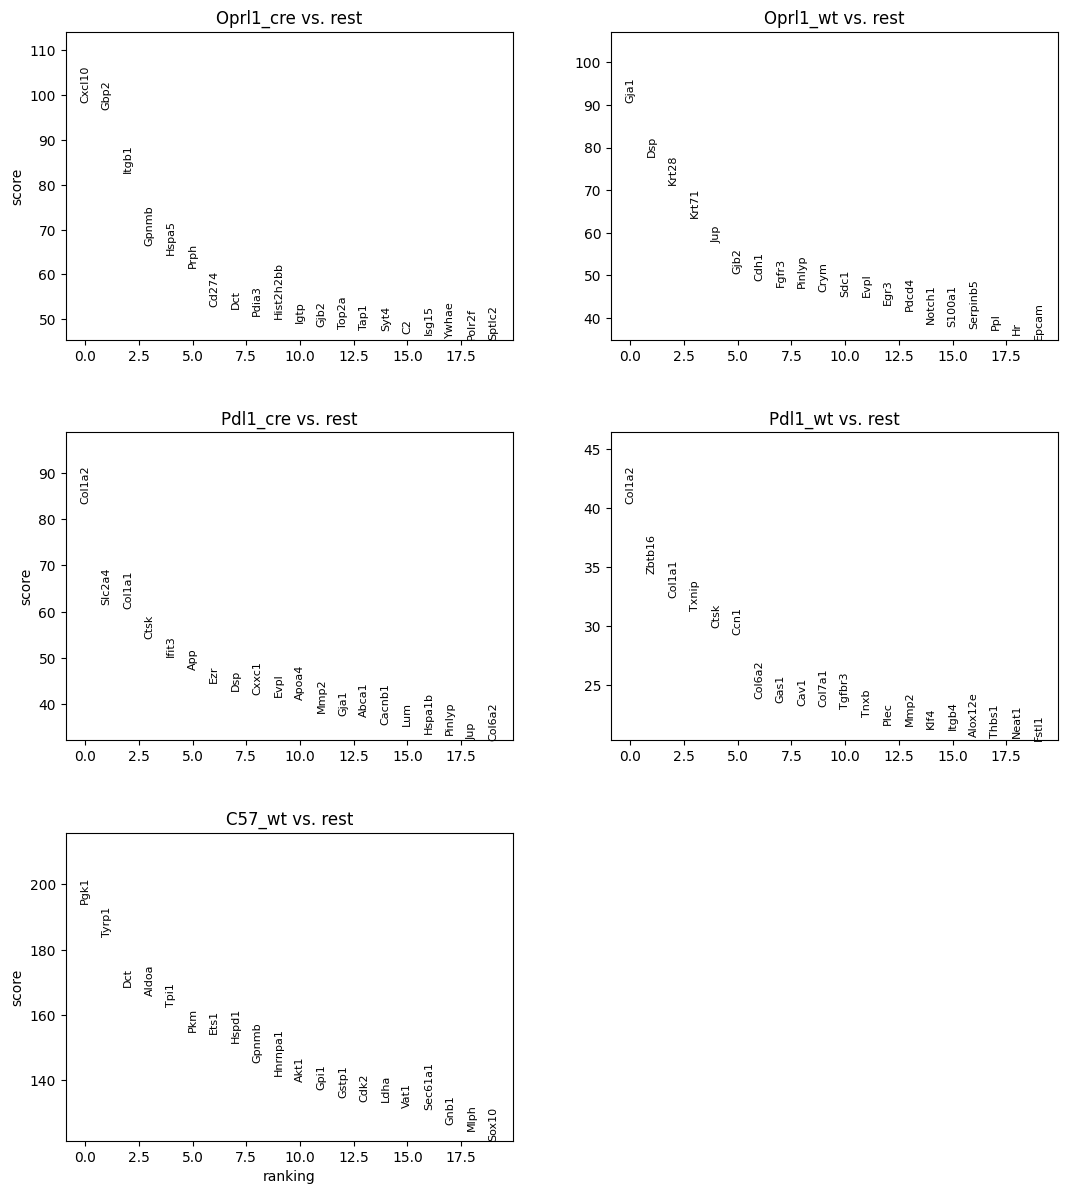

In [47]:
# Run DE between groups in adata.obs["condition"]
sc.tl.rank_genes_groups(
    ad,
    groupby="condition",          # column in .obs
    method="t-test",              # or "wilcoxon" / "logreg"
    reference="control_group"     # pick which group to compare against
)

# Inspect results
sc.pl.rank_genes_groups(ad, n_genes=20, sharey=False, ncols= 2)

## Running DGE using built in scanpy functionality (non bulk)

In [26]:
ad.X = ad.layers['transformed'].copy()


=== Pdl1_wt+C57_vs_Pdl1_cre ===
     gene  logfoldchange           pval       pval_adj
0    Gja1       2.397503   0.000000e+00   0.000000e+00
1     Dsp       1.553611   0.000000e+00   0.000000e+00
2   Krt28       5.479563   0.000000e+00   0.000000e+00
3   Krt71       5.037430   0.000000e+00   0.000000e+00
4     Jup       1.385665   0.000000e+00   0.000000e+00
5    Evpl       1.963276   0.000000e+00   0.000000e+00
6  Pinlyp       3.159889   0.000000e+00   0.000000e+00
7    Crym       6.329122   0.000000e+00   0.000000e+00
8   Fgfr3       1.736825  1.924264e-269  1.030253e-268
9    Egr3       1.678635  6.362383e-266  3.388307e-265


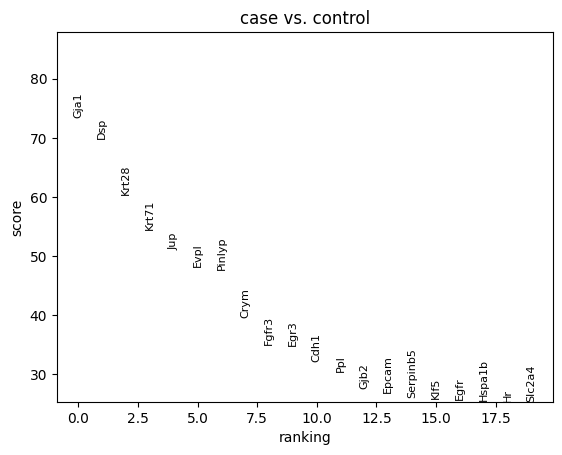


=== Pdl1_wt_vs_Pdl1_cre ===
        gene  logfoldchange           pval       pval_adj
0      Krt28       4.912403   0.000000e+00   0.000000e+00
1       Gja1       1.359054  7.563884e-272  1.893240e-268
2      Krt71       4.138864  7.836570e-265  1.307662e-261
3       Cct3       1.194675  7.442803e-232  9.314668e-229
4      Hspa5       0.812950  6.530910e-194  6.538747e-191
5      Ywhae       0.797056  6.781269e-188  5.657839e-185
6  Hist2h2bb       1.705610  2.180813e-183  1.559593e-180
7     Ctnnb1       0.751463  4.406810e-161  2.757561e-158
8       Rab7       0.540330  1.693154e-157  9.417698e-155
9      Gpnmb       2.341161  2.694620e-157  1.348927e-154


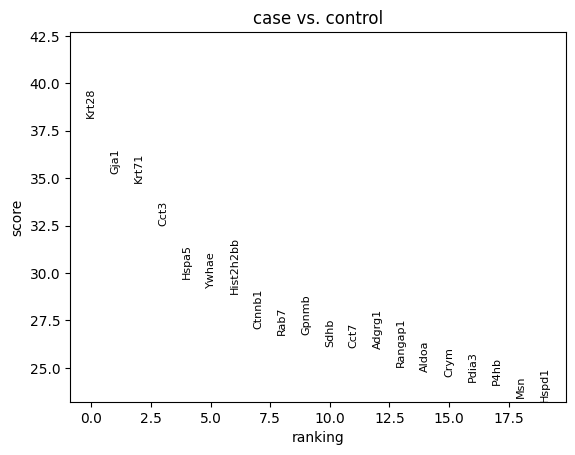


=== Oprl1_cre_vs_C57_wt ===
     gene  logfoldchange           pval       pval_adj
0   Krt71       5.568974   0.000000e+00   0.000000e+00
1   Krt28       5.591274   0.000000e+00   0.000000e+00
2    Gja1       2.519449   0.000000e+00   0.000000e+00
3     Dsp       1.507485   0.000000e+00   0.000000e+00
4    Gjb2       3.598141   0.000000e+00   0.000000e+00
5     Jup       1.347086   0.000000e+00   0.000000e+00
6    Xist       5.210833   0.000000e+00   0.000000e+00
7    Gbp2       2.097808   0.000000e+00   0.000000e+00
8  Pinlyp       4.784083   0.000000e+00   0.000000e+00
9    Crym       6.243680  3.492100e-305  2.660799e-304


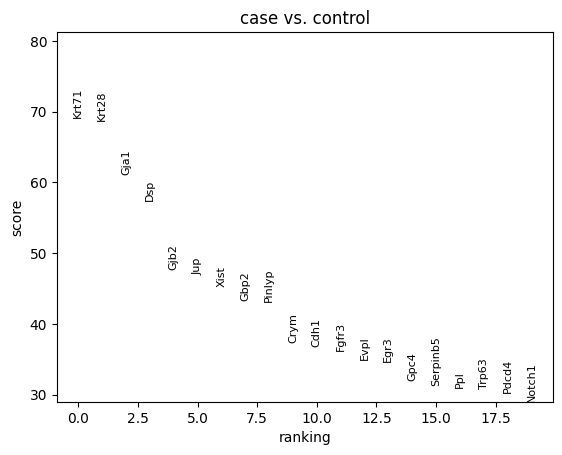

In [27]:
import scanpy as sc
import pandas as pd

# Your dictionary

results_scanpy = {}

for name, spec in comparisons.items():
    case_conditions = spec["case"]
    ctrl_conditions = spec["control"]

    # Make a temporary grouping column in .obs
    ad.obs["group_DE"] = "rest"
    ad.obs.loc[ad.obs["condition"].isin(case_conditions), "group_DE"] = "case"
    ad.obs.loc[ad.obs["condition"].isin(ctrl_conditions), "group_DE"] = "control"

    # Subset only case + control cells
    ad_sub = ad[ad.obs["group_DE"].isin(["case","control"])].copy()

    # Run DE
    sc.tl.rank_genes_groups(
        ad_sub,
        groupby="group_DE",
        method="wilcoxon",      # or "t-test"
        reference="control"     # always compare case vs control
    )

    # Save results to a tidy DataFrame
    de_res = ad_sub.uns["rank_genes_groups"]
    case_group = "case"

    df = pd.DataFrame({
        "gene": de_res["names"][case_group],
        "logfoldchange": de_res["logfoldchanges"][case_group],
        "pval": de_res["pvals"][case_group],
        "pval_adj": de_res["pvals_adj"][case_group],
    })
    results_scanpy[name] = df

    print(f"\n=== {name} ===")
    print(df.head(10))

    # Quick plot for top genes
    sc.pl.rank_genes_groups(ad_sub, n_genes=20, sharey=False, ncols=2, title=name)